In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
teachers = pd.read_csv("data/Teachers.csv")
courses = pd.read_csv("data/Courses.csv")
transactions = pd.read_csv("data/Transactions.csv")

In [5]:
print("Teachers Shape:", teachers.shape)
print("Courses Shape:", courses.shape)
print("Transactions Shape:", transactions.shape)

Teachers Shape: (60, 7)
Courses Shape: (60, 8)
Transactions Shape: (10000, 7)


In [6]:
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


In [7]:
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [8]:
transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042


In [9]:
teachers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     object 
 1   TeacherName        60 non-null     object 
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     object 
 4   Expertise          60 non-null     object 
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 3.4+ KB


In [10]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     object 
 1   CourseName      60 non-null     object 
 2   CourseCategory  60 non-null     object 
 3   CourseType      60 non-null     object 
 4   CourseLevel     60 non-null     object 
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.9+ KB


In [11]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    10000 non-null  object 
 1   UserID           10000 non-null  object 
 2   CourseID         10000 non-null  object 
 3   TransactionDate  10000 non-null  object 
 4   Amount           10000 non-null  float64
 5   PaymentMethod    10000 non-null  object 
 6   TeacherID        10000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.0+ KB


In [12]:
print("Teachers Missing Values")
print(teachers.isnull().sum())

print("\nCourses Missing Values")
print(courses.isnull().sum())

print("\nTransactions Missing Values")
print(transactions.isnull().sum())

Teachers Missing Values
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

Courses Missing Values
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Transactions Missing Values
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


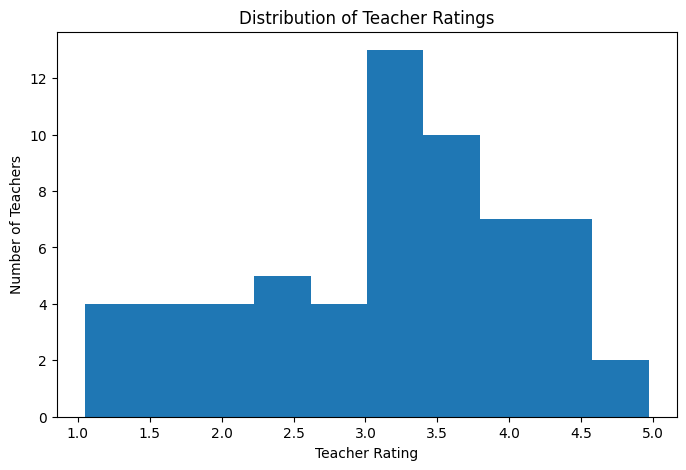

In [13]:
plt.figure(figsize=(8,5))

plt.hist(teachers["TeacherRating"], bins=10)

plt.title("Distribution of Teacher Ratings")
plt.xlabel("Teacher Rating")
plt.ylabel("Number of Teachers")

plt.show()

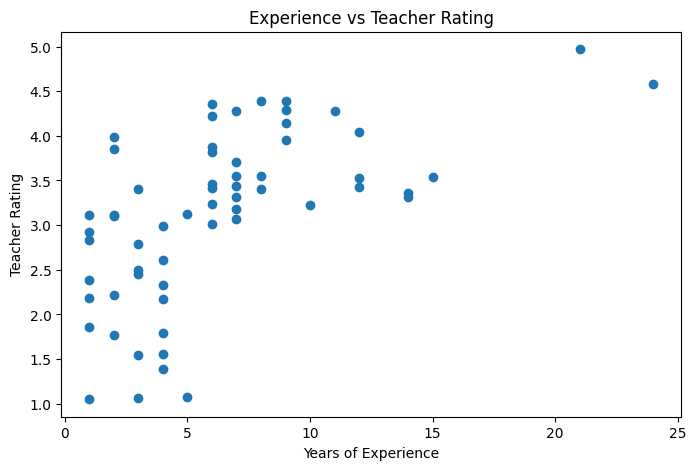

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    teachers["YearsOfExperience"],
    teachers["TeacherRating"]
)

plt.title("Experience vs Teacher Rating")
plt.xlabel("Years of Experience")
plt.ylabel("Teacher Rating")

plt.show()

In [15]:
correlation = teachers["YearsOfExperience"].corr(
    teachers["TeacherRating"]
)

print("Correlation:", correlation)

Correlation: 0.5980353982941563


In [16]:
teachers.groupby("Expertise")["TeacherRating"].mean().sort_values(ascending=False)

Expertise
Marketing                  4.290000
Machine Learning           4.234000
Programming                3.950000
Cybersecurity              3.468889
Finance                    3.265000
Artificial Intelligence    3.173333
Digital Marketing          3.050000
Data Science               3.030000
Project Management         2.664000
Web Development            2.514000
Design                     2.290000
Business                   2.245000
Name: TeacherRating, dtype: float64

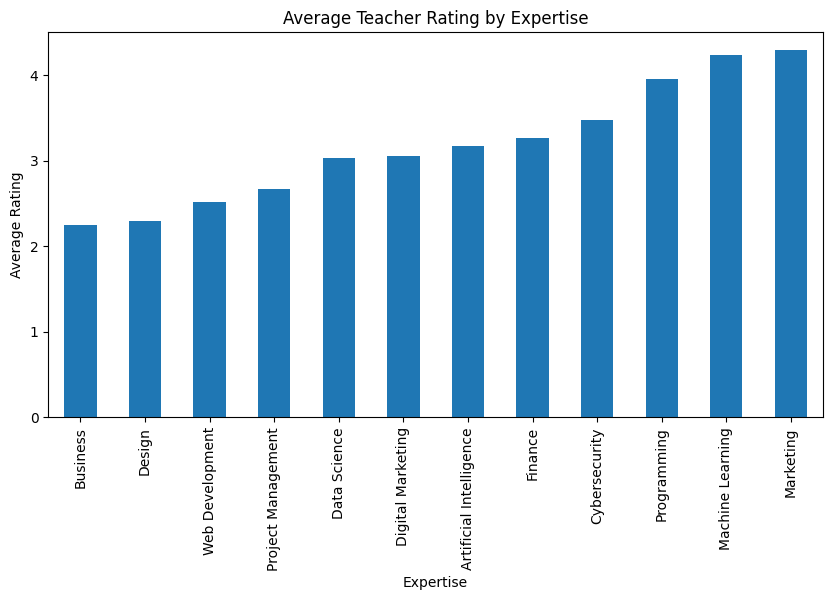

In [17]:
teachers.groupby("Expertise")["TeacherRating"]\
.mean()\
.sort_values()\
.plot(kind="bar", figsize=(10,5))

plt.title("Average Teacher Rating by Expertise")
plt.xlabel("Expertise")
plt.ylabel("Average Rating")

plt.show()

In [18]:
avg_teacher_rating = teachers["TeacherRating"].mean()

print("Average Teacher Rating:", round(avg_teacher_rating,2))

Average Teacher Rating: 3.12


In [19]:
avg_course_rating = courses["CourseRating"].mean()

print("Average Course Rating:", round(avg_course_rating,2))

Average Course Rating: 3.1


In [20]:
teacher_course = pd.merge(
    teachers[["TeacherID","TeacherRating"]],
    transactions[["TeacherID","CourseID"]],
    on="TeacherID"
)

teacher_course = pd.merge(
    teacher_course,
    courses[["CourseID","CourseRating"]],
    on="CourseID"
)

corr = teacher_course["TeacherRating"].corr(
    teacher_course["CourseRating"]
)

print("Teacher Rating vs Course Rating Correlation:", corr)

Teacher Rating vs Course Rating Correlation: -0.0015769899837392745


In [21]:
enrollment = transactions.groupby("TeacherID").size()

teacher_enrollment = pd.merge(
    teachers,
    enrollment.reset_index(name="Enrollments"),
    on="TeacherID"
)

teacher_enrollment.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,Enrollments
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24,36
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14,68
2,TC00003,Amber Torres,32,Male,Design,4,1.56,59
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39,47
4,TC00005,David Williams,34,Male,Finance,2,3.11,47


In [22]:
corr = teacher_enrollment["TeacherRating"].corr(
    teacher_enrollment["Enrollments"]
)

print("Enrollment Influence Ratio:", corr)

Enrollment Influence Ratio: 0.3182868450742986
